In [18]:
# import required libraries for clustering
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D

In [19]:
retail = pd.read_csv(r"C:\Users\Pramod.SMITHUREN\OneDrive - Smith Uren Group\Desktop\PP - Anaconda\Capstone Project\OnlineRetail.csv", sep=",", encoding="ISO-8859-1", header=0)

# Data Exploration & Cleaning

In [21]:
# Diplaying the first few row of the dataset which will help me decide what features can be added or removed.
retail.head(8)

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom


In [22]:
# Total number of rows and coloumns. I m really happy with the size of the dataset.
retail.shape

(541909, 9)

In [23]:
retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   index        541909 non-null  int64  
 1   InvoiceNo    541909 non-null  object 
 2   StockCode    541909 non-null  object 
 3   Description  540455 non-null  object 
 4   Quantity     541909 non-null  int64  
 5   InvoiceDate  541909 non-null  object 
 6   UnitPrice    541909 non-null  float64
 7   CustomerID   406829 non-null  float64
 8   Country      541909 non-null  object 
dtypes: float64(2), int64(2), object(5)
memory usage: 37.2+ MB


# Data Cleaning

In [25]:
# Calculating the Missing Values % contribution in Dataframe
# 24.93 % of customer ID is missing on the dataset. Which means we wont be able to contact those customers, which means its better to remove from the dataset.
df_null = round(100*(retail.isnull().sum())/len(retail), 2)
df_null

index           0.00
InvoiceNo       0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
CustomerID     24.93
Country         0.00
dtype: float64

In [26]:
# Droping rows having missing values as I explianed earlier. Most of them have got Customer ID missing. only 0.27% did not have the information on
# description which means we dont knwo what they bought. its better to drop them off too.

retail = retail.dropna()
retail.shape

(406829, 9)

In [27]:
df_null = round(100*(retail.isnull().sum())/len(retail), 2)
df_null

index          0.0
InvoiceNo      0.0
StockCode      0.0
Description    0.0
Quantity       0.0
InvoiceDate    0.0
UnitPrice      0.0
CustomerID     0.0
Country        0.0
dtype: float64

In [28]:
retail.dtypes

index            int64
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

In [29]:
# Changing the datatype of Customer ID to string, Just in case
retail['CustomerID'] = retail['CustomerID'].astype(int).astype(str)

In [30]:
retail.dtypes

index            int64
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID      object
Country         object
dtype: object

In [31]:
# New Attribute 1 : Monetary
# Multiplying Qty * Unitprice on a new column called Amount - 
# Calculating the total amount spent based on the CustomerID using groupby.
# Saved the output into a seperate DF called rfm_m
retail['Amount'] = retail['Quantity']*retail['UnitPrice']
rfm_m = retail.groupby('CustomerID')['Amount'].sum()
rfm_m = rfm_m.reset_index()
rfm_m.head()

,CustomerID,Amount
0,12346,0.00
1,12347,4310.00
2,12348,1797.24
3,12349,1757.55
4,12350,334.40


In [32]:
# New Attribute 2 : Frequency
# using CustomerID and counting the number of invoices for a customer, adding a new column Frequency to show the value. 
# Saved the output into a separate df called rfm_f
rfm_f = retail.groupby('CustomerID')['InvoiceNo'].count()
rfm_f = rfm_f.reset_index()
rfm_f.columns = ['CustomerID', 'Frequency']
rfm_f.head()

,CustomerID,Frequency
0,12346,2
1,12347,182
2,12348,31
3,12349,73
4,12350,17


In [33]:
# Now merging both df with new attributes Amount & Frequency 

rfm = pd.merge(rfm_m, rfm_f, on='CustomerID', how='inner')
rfm.head()

,CustomerID,Amount,Frequency
0,12346,0.00,2
1,12347,4310.00,182
2,12348,1797.24,31
3,12349,1757.55,73
4,12350,334.40,17


In [34]:
# Changed the date format into the right format.
retail['InvoiceDate'] = pd.to_datetime(retail['InvoiceDate'], format='%m/%d/%Y %H:%M')


In [35]:
# Compute the maximum date to know the last transaction date
# Finding the latest invoice date using MAX function

max_date = max(retail['InvoiceDate'])
max_date

Timestamp('2011-12-09 12:50:00')

In [36]:
# Compute the difference between max date and transaction date
# Added a new column called Diff which shows the difference.

retail['Diff'] = max_date - retail['InvoiceDate']
retail.head()

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Amount,Diff
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,373 days 04:24:00
1,1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,373 days 04:24:00
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,373 days 04:24:00
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,373 days 04:24:00
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,373 days 04:24:00


In [37]:
# Compute recency of customer
# Now I got which customer has how many days of gap since their last visit - based on Customer ID.
rfm_p = retail.groupby('CustomerID')['Diff'].min()
rfm_p = rfm_p.reset_index()
rfm_p.head()

,CustomerID,Diff
0,12346,325 days 02:33:00
1,12347,1 days 20:58:00
2,12348,74 days 23:37:00
3,12349,18 days 02:59:00
4,12350,309 days 20:49:00


In [38]:
# Extract number of days only
# Just rounding up he days..

rfm_p['Diff'] = rfm_p['Diff'].dt.days
rfm_p.head()

,CustomerID,Diff
0,12346,325
1,12347,1
2,12348,74
3,12349,18
4,12350,309


In [39]:
# Merge the dataframes to get the final RFM dataframe
# Adding this new feature to the previosu df.

# Exception - Customer 12346 might hav used a gift voucher, a prezzy card or may be return voucher to be used withing a certain period of time
# which does not get counted as Amount spent because the amount had alraeady beent spent.

rfm = pd.merge(rfm, rfm_p, on='CustomerID', how='inner')
rfm.columns = ['CustomerID', 'Amount', 'Frequency', 'Recency']
rfm.head()

,CustomerID,Amount,Frequency,Recency
0,12346,0.00,2,325
1,12347,4310.00,182,1
2,12348,1797.24,31,74
3,12349,1757.55,73,18
4,12350,334.40,17,309


In [40]:
rfm_raw_data = rfm

In [41]:
# Calculate the summary statistics for 'Amount'
amount_summary = rfm['Amount'].describe()

# Print the title and the summary statistics
print("Summary Statistics for Amount:\n", amount_summary)


Summary Statistics for Amount:
 count      4372.000000
mean       1898.459701
std        8219.345141
min       -4287.630000
25%         293.362500
50%         648.075000
75%        1611.725000
max      279489.020000
Name: Amount, dtype: float64


In [42]:
# Summary statistics for 'Frequency'
frequency_summary = rfm['Frequency'].describe()
print("\nSummary Statistics for Frequency:\n", frequency_summary)


Summary Statistics for Frequency:
 count    4372.000000
mean       93.053294
std       232.471608
min         1.000000
25%        17.000000
50%        42.000000
75%       102.000000
max      7983.000000
Name: Frequency, dtype: float64


In [43]:
# Summary statistics for 'Recency'
recency_summary = rfm['Recency'].describe()
print("\nSummary Statistics for Recency:\n", recency_summary)


Summary Statistics for Recency:
 count    4372.000000
mean       91.047118
std       100.765435
min         0.000000
25%        16.000000
50%        49.000000
75%       142.000000
max       373.000000
Name: Recency, dtype: float64


# Creating a scatter plot

The code below creates a scatter plot that helps me visualize the relationship between Amount and Frequency, with the Recency values providing additional information through color coding. IT also helps me identify patterns and correlations between these three variables in my RFM analysis.

# Stock code

In [47]:
# I have careated this code just to use on my presentation. Otherwise I was happy with the previous code

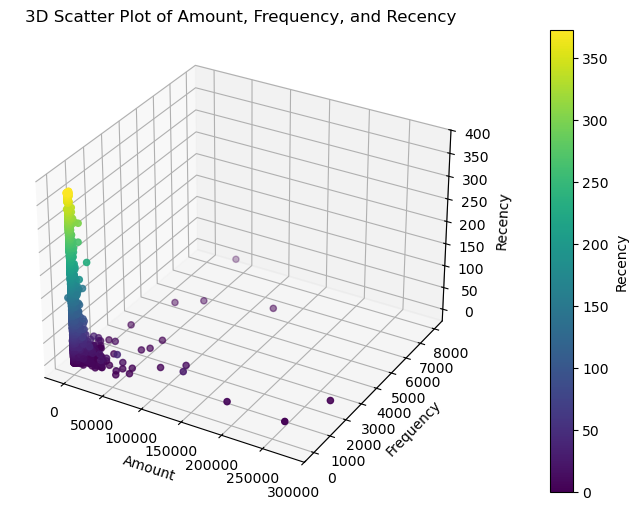

In [48]:
# Create a figure with 3D projection
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# Create a 3D scatter plot
scatter = ax.scatter(rfm['Amount'], rfm['Frequency'], rfm['Recency'], c=rfm['Recency'], cmap='viridis')

# Add color bar
cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Recency')

# Set axis labels
ax.set_xlabel('Amount')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')

# Set plot title
ax.set_title('3D Scatter Plot of Amount, Frequency, and Recency')

# Show the plot
plt.show()

# Outliers Variable Distribution

This visualization helps identify any outliers in the Amount, Frequency, and Recency attributes, which can be useful for further analysis and preprocessing steps, such as handling these outliers appropriately.

Text(0.5, 0, 'Attributes')

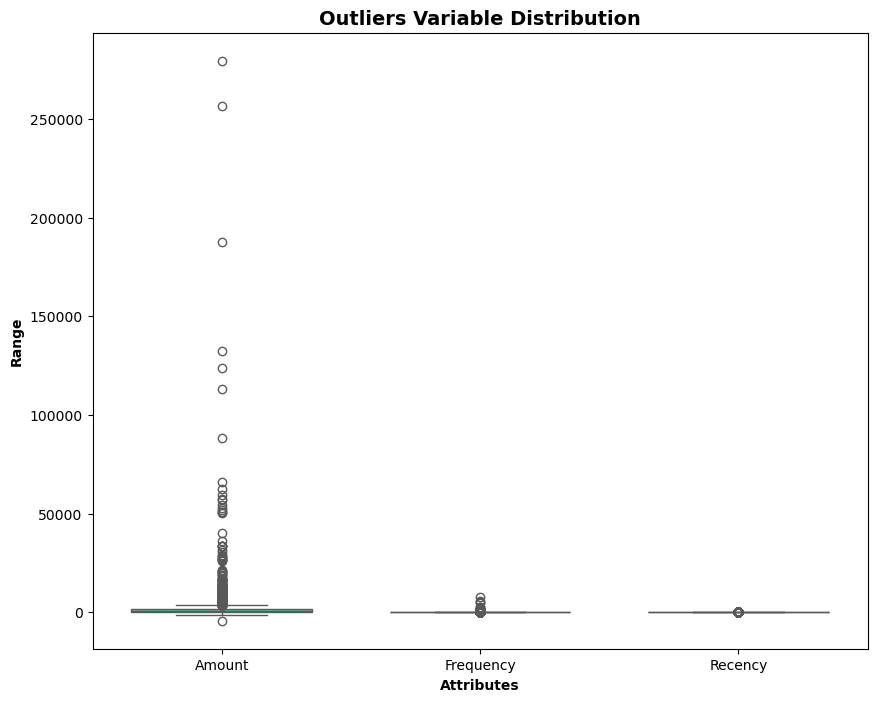

In [51]:
# Outlier Analysis of Amount Frequency and Recency
attributes = ['Amount','Frequency','Recency']
plt.rcParams['figure.figsize'] = [10,8]
sns.boxplot(data = rfm[attributes], orient="v", palette="Set2" ,whis=1.5,saturation=1, width=0.7)
plt.title("Outliers Variable Distribution", fontsize = 14, fontweight = 'bold')
plt.ylabel("Range", fontweight = 'bold')
plt.xlabel("Attributes", fontweight = 'bold')

# 2D Visualisation of outliers

This visualization helps in understanding how these RFM attributes interact with each other, which can be useful for customer segmentation and analysis.

In [54]:
# Create a copy of the original DataFrame before removing outliers - Just so I can compare before and after if and when I need to.
rfm_before = rfm.copy()

# Removing outlier for Amount

using the Interquartile Range (IQR) method to identify and remove outliers in a dataset. This method is particularly effective because it is not influenced by the extremes of the data, making it a robust measure. Here’s why and how it works:

How IQR Method Works:
Calculate Q1 and Q3:

Q1 (First Quartile): The value below which 25% of the data falls.
Q3 (Third Quartile): The value below which 75% of the data falls.
Calculate IQR:

IQR: The range between Q1 and Q3 (IQR = Q3 - Q1). This measures the middle 50% of the data.
Determine the Outlier Boundaries:

Lower Bound: Q1 - 1.5 * IQR
Upper Bound: Q3 + 1.5 * IQR
Any data point outside these boundaries is considered an outlier.

I have choosen IQR over Z-Score & Percentile method.

This code performs outlier removal for the Amount attribute in the rfm DataFrame using the Interquartile Range (IQR) method. It then visualizes the effect of outlier removal by displaying side-by-side scatter plots before and after the outlier removal.

Before removing outliers for Amount:
              Amount    Frequency      Recency
count    4372.000000  4372.000000  4372.000000
mean     1898.459701    93.053294    91.047118
std      8219.345141   232.471608   100.765435
min     -4287.630000     1.000000     0.000000
25%       293.362500    17.000000    16.000000
50%       648.075000    42.000000    49.000000
75%      1611.725000   102.000000   142.000000
max    279489.020000  7983.000000   373.000000
Number of data points before removing outliers: 4372
After removing outliers for Amount:
            Amount    Frequency      Recency
count  3949.000000  3949.000000  3949.000000
mean    855.138241    61.925298    98.465688
std     813.941089    77.104334   102.483044
min   -1592.490000     1.000000     0.000000
25%     264.620000    16.000000    20.000000
50%     567.360000    35.000000    56.000000
75%    1201.490000    81.000000   157.000000
max    3580.130000   977.000000   373.000000
Number of data points after removing outliers 

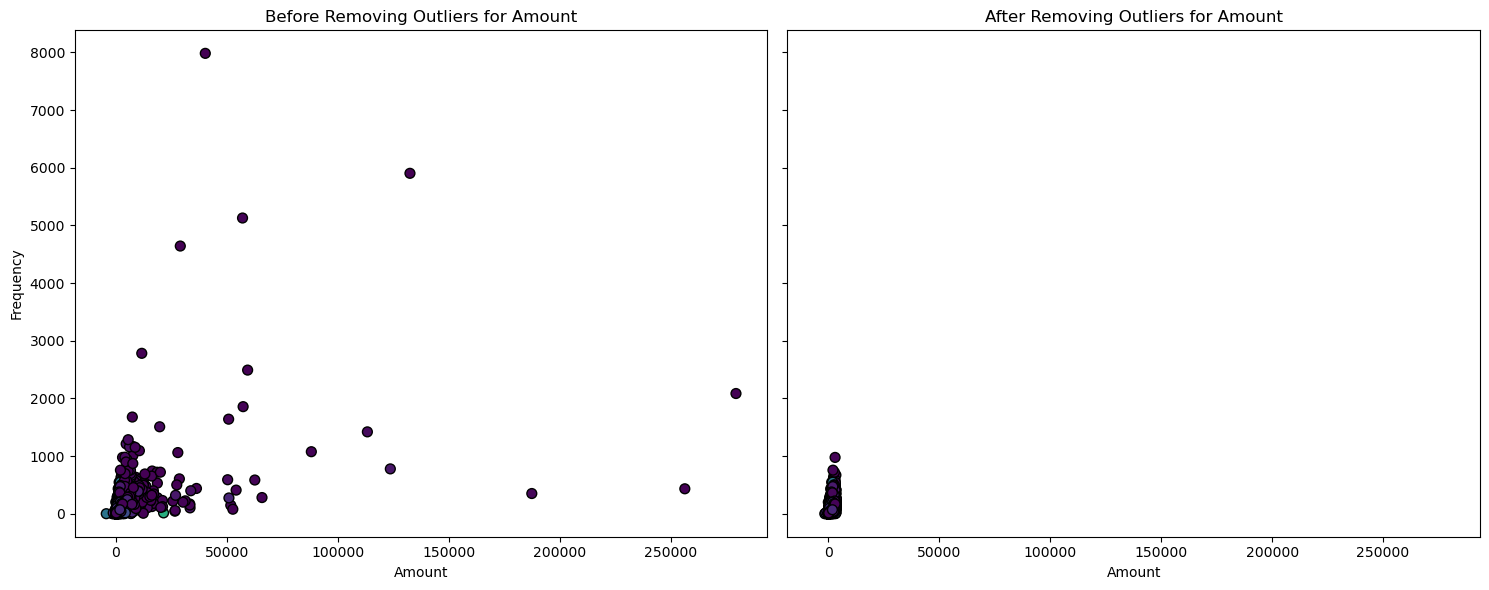

In [60]:
# Final Final  1 - Outlier removal for Amount

# Calculate the IQR for Amount
Q1_amount = rfm.Amount.quantile(0.25)
Q3_amount = rfm.Amount.quantile(0.75)
IQR_amount = Q3_amount - Q1_amount

# Display descriptive statistics before removing outliers
print("Before removing outliers for Amount:")
print(rfm.describe())

# Display the number of data points before removing outliers
print(f"Number of data points before removing outliers: {rfm.shape[0]}")

# Filter the data
rfm_after_amount = rfm[(rfm.Amount >= Q1_amount - 1.5 * IQR_amount) & (rfm.Amount <= Q3_amount + 1.5 * IQR_amount)]

# Display descriptive statistics after removing outliers
print("After removing outliers for Amount:")
print(rfm_after_amount.describe())

# Display the number of data points after removing outliers
print(f"Number of data points after removing outliers for Amount: {rfm_after_amount.shape[0]}")

# Plot side-by-side scatter plots to display the difference
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)

# Scatter plot before removing outliers
axes[0].scatter(rfm['Amount'], rfm['Frequency'], c=rfm['Recency'], cmap='viridis', marker='o', edgecolor='k', s=50)
axes[0].set_title('Before Removing Outliers for Amount')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')

# Scatter plot after removing outliers
axes[1].scatter(rfm_after_amount['Amount'], rfm_after_amount['Frequency'], c=rfm_after_amount['Recency'], cmap='viridis', marker='o', edgecolor='k', s=50)
axes[1].set_title('After Removing Outliers for Amount')
axes[1].set_xlabel('Amount')

plt.tight_layout()
plt.show()


Before removing outliers for Frequency:
            Amount    Frequency      Recency
count  3949.000000  3949.000000  3949.000000
mean    855.138241    61.925298    98.465688
std     813.941089    77.104334   102.483044
min   -1592.490000     1.000000     0.000000
25%     264.620000    16.000000    20.000000
50%     567.360000    35.000000    56.000000
75%    1201.490000    81.000000   157.000000
max    3580.130000   977.000000   373.000000
Number of data points before removing outliers: 3949
After removing outliers for Frequency:
            Amount    Frequency      Recency
count  3697.000000  3697.000000  3697.000000
mean    771.363098    46.658101   103.272383
std     740.646223    41.705211   103.798588
min   -1592.490000     1.000000     0.000000
25%     248.100000    15.000000    22.000000
50%     508.460000    32.000000    60.000000
75%    1046.560000    68.000000   169.000000
max    3563.850000   178.000000   373.000000
Number of data points after removing outliers for Frequenc

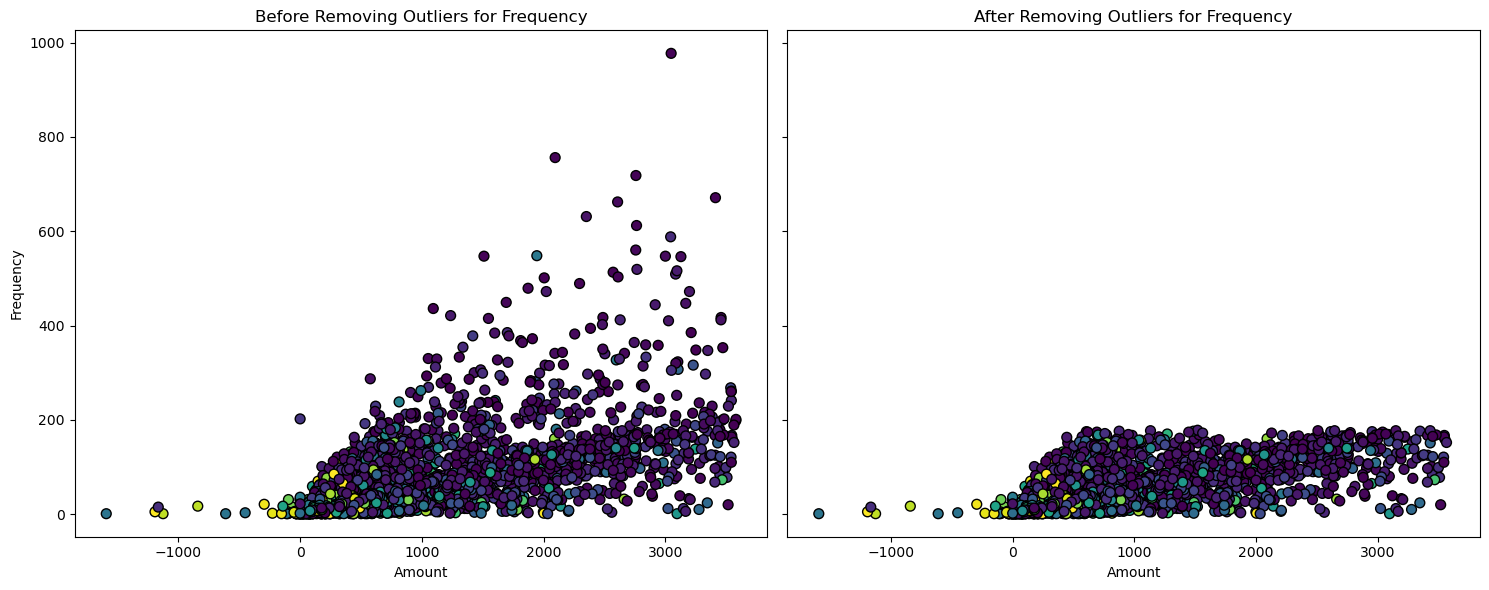

In [61]:
# Final Final 2 - Frequency
# Calculate the IQR for Frequency
Q1_frequency = rfm_after_amount.Frequency.quantile(0.25)
Q3_frequency = rfm_after_amount.Frequency.quantile(0.75)
IQR_frequency = Q3_frequency - Q1_frequency

# Display descriptive statistics before removing outliers
print("Before removing outliers for Frequency:")
print(rfm_after_amount.describe())

# Display the number of data points before removing outliers
print(f"Number of data points before removing outliers: {rfm_after_amount.shape[0]}")

# Filter the data
rfm_after_frequency = rfm_after_amount[(rfm_after_amount.Frequency >= Q1_frequency - 1.5 * IQR_frequency) & (rfm_after_amount.Frequency <= Q3_frequency + 1.5 * IQR_frequency)]

# Display descriptive statistics after removing outliers
print("After removing outliers for Frequency:")
print(rfm_after_frequency.describe())

# Display the number of data points after removing outliers for Frequency
print(f"Number of data points after removing outliers for Frequency: {rfm_after_frequency.shape[0]}")

# Plot side-by-side scatter plots to display the difference
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)

# Scatter plot before removing outliers
axes[0].scatter(rfm_after_amount['Amount'], rfm_after_amount['Frequency'], c=rfm_after_amount['Recency'], cmap='viridis', marker='o', edgecolor='k', s=50)
axes[0].set_title('Before Removing Outliers for Frequency')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')

# Scatter plot after removing outliers
axes[1].scatter(rfm_after_frequency['Amount'], rfm_after_frequency['Frequency'], c=rfm_after_frequency['Recency'], cmap='viridis', marker='o', edgecolor='k', s=50)
axes[1].set_title('After Removing Outliers for Frequency')
axes[1].set_xlabel('Amount')

plt.tight_layout()
plt.show()


Before removing outliers for Recency:
            Amount    Frequency      Recency
count  3697.000000  3697.000000  3697.000000
mean    771.363098    46.658101   103.272383
std     740.646223    41.705211   103.798588
min   -1592.490000     1.000000     0.000000
25%     248.100000    15.000000    22.000000
50%     508.460000    32.000000    60.000000
75%    1046.560000    68.000000   169.000000
max    3563.850000   178.000000   373.000000
Number of data points before removing outliers: 3697
After removing outliers for Recency:
            Amount    Frequency      Recency
count  3697.000000  3697.000000  3697.000000
mean    771.363098    46.658101   103.272383
std     740.646223    41.705211   103.798588
min   -1592.490000     1.000000     0.000000
25%     248.100000    15.000000    22.000000
50%     508.460000    32.000000    60.000000
75%    1046.560000    68.000000   169.000000
max    3563.850000   178.000000   373.000000
Number of data points after removing outliers for Recency: 369

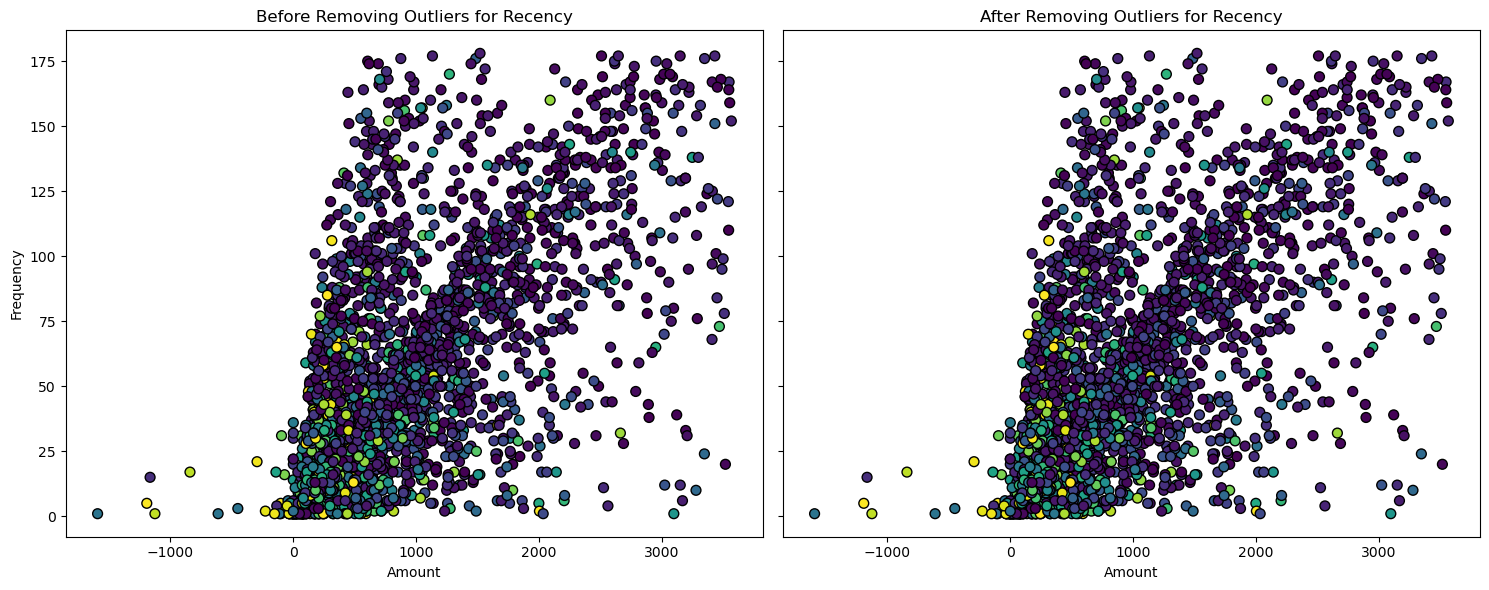

In [62]:
# Final 3 - Recency
# Calculate the IQR for Recency
Q1_recency = rfm_after_frequency.Recency.quantile(0.25)
Q3_recency = rfm_after_frequency.Recency.quantile(0.75)
IQR_recency = Q3_recency - Q1_recency

# Display descriptive statistics before removing outliers
print("Before removing outliers for Recency:")
print(rfm_after_frequency.describe())

# Display the number of data points before removing outliers
print(f"Number of data points before removing outliers: {rfm_after_frequency.shape[0]}")

# Filter the data
rfm_after_recency = rfm_after_frequency[(rfm_after_frequency.Recency >= Q1_recency - 1.5 * IQR_recency) & (rfm_after_frequency.Recency <= Q3_recency + 1.5 * IQR_recency)]

# Display descriptive statistics after removing outliers
print("After removing outliers for Recency:")
print(rfm_after_recency.describe())

# Display the number of data points after removing outliers
print(f"Number of data points after removing outliers for Recency: {rfm_after_recency.shape[0]}")

# Plot side-by-side scatter plots to display the difference
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)

# Scatter plot before removing outliers
axes[0].scatter(rfm_after_frequency['Amount'], rfm_after_frequency['Frequency'], c=rfm_after_frequency['Recency'], cmap='viridis', marker='o', edgecolor='k', s=50)
axes[0].set_title('Before Removing Outliers for Recency')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')

# Scatter plot after removing outliers
axes[1].scatter(rfm_after_recency['Amount'], rfm_after_recency['Frequency'], c=rfm_after_recency['Recency'], cmap='viridis', marker='o', edgecolor='k', s=50)
axes[1].set_title('After Removing Outliers for Recency')
axes[1].set_xlabel('Amount')

plt.tight_layout()
plt.show()


In [63]:
# Descriptive statistics for 'Amount', 'Frequency', and 'Recency' before outlier removal
print("Descriptive statistics before outlier removal:")
print(rfm_before[['Amount', 'Frequency', 'Recency']].describe())

# Descriptive statistics for 'Amount', 'Frequency', and 'Recency' after outlier removal
print("Descriptive statistics after outlier removal:")
print(rfm_after_recency[['Amount', 'Frequency', 'Recency']].describe())


Descriptive statistics before outlier removal:
              Amount    Frequency      Recency
count    4372.000000  4372.000000  4372.000000
mean     1898.459701    93.053294    91.047118
std      8219.345141   232.471608   100.765435
min     -4287.630000     1.000000     0.000000
25%       293.362500    17.000000    16.000000
50%       648.075000    42.000000    49.000000
75%      1611.725000   102.000000   142.000000
max    279489.020000  7983.000000   373.000000
Descriptive statistics after outlier removal:
            Amount    Frequency      Recency
count  3697.000000  3697.000000  3697.000000
mean    771.363098    46.658101   103.272383
std     740.646223    41.705211   103.798588
min   -1592.490000     1.000000     0.000000
25%     248.100000    15.000000    22.000000
50%     508.460000    32.000000    60.000000
75%    1046.560000    68.000000   169.000000
max    3563.850000   178.000000   373.000000


Text(0, 0.5, 'Frequency')

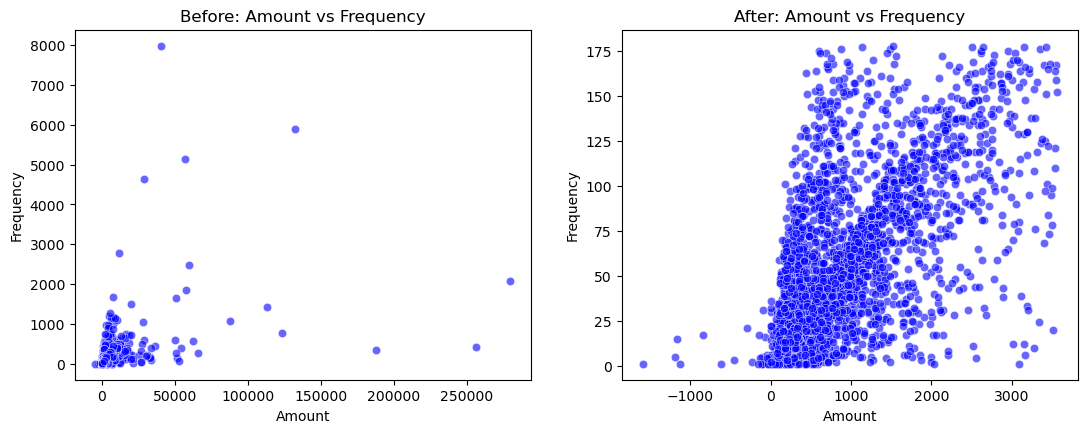

In [64]:

# Create a figure with 2 rows and 3 columns for side-by-side comparisons
plt.figure(figsize=(20, 10))

# Before Outlier Removal: Amount vs Frequency
plt.subplot(2, 3, 1)
sns.scatterplot(x='Amount', y='Frequency', data=rfm_before, color='blue', alpha=0.6)
plt.title('Before: Amount vs Frequency')
plt.xlabel('Amount')
plt.ylabel('Frequency')


# After Outlier Removal: Amount vs Frequency
plt.subplot(2, 3, 2)
sns.scatterplot(x='Amount', y='Frequency', data=rfm_after_recency, color='blue', alpha=0.6)
plt.title('After: Amount vs Frequency')
plt.xlabel('Amount')
plt.ylabel('Frequency')




In [65]:
print(rfm_before.head())
print(rfm_before.shape)

print(rfm_after_recency.head())
print(rfm_after_recency.shape)

  CustomerID   Amount  Frequency  Recency
0      12346     0.00          2      325
1      12347  4310.00        182        1
2      12348  1797.24         31       74
3      12349  1757.55         73       18
4      12350   334.40         17      309
(4372, 4)
  CustomerID   Amount  Frequency  Recency
0      12346     0.00          2      325
2      12348  1797.24         31       74
3      12349  1757.55         73       18
4      12350   334.40         17      309
5      12352  1545.41         95       35
(3697, 4)


Text(0, 0.5, 'Recency')

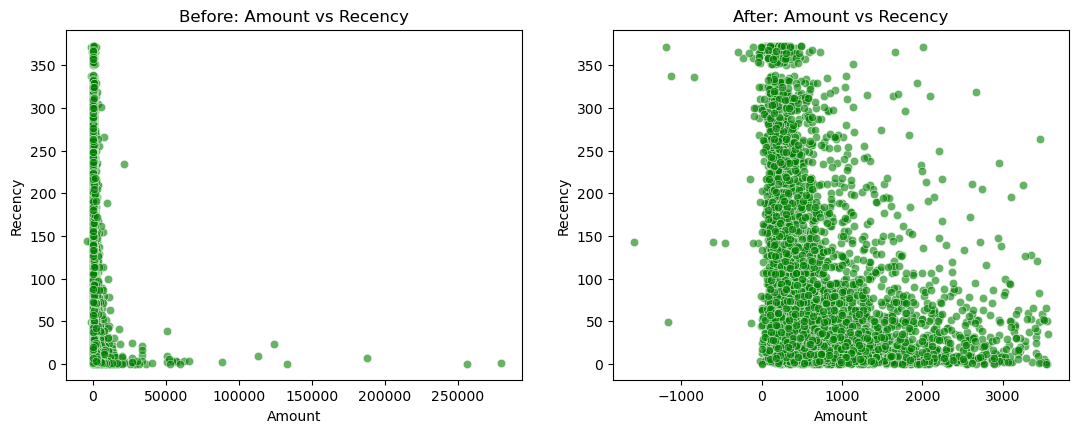

In [66]:
# Before Outlier Removal: Amount vs Recency
plt.figure(figsize=(20, 10))

plt.subplot(2, 3, 1)
sns.scatterplot(x='Amount', y='Recency', data=rfm_before, color='green', alpha=0.6)
plt.title('Before: Amount vs Recency')
plt.xlabel('Amount')
plt.ylabel('Recency')

# After Outlier Removal: Amount vs Recency
plt.subplot(2, 3, 2)
sns.scatterplot(x='Amount', y='Recency', data=rfm_after_recency, color='green', alpha=0.6)
plt.title('After: Amount vs Recency')
plt.xlabel('Amount')
plt.ylabel('Recency')


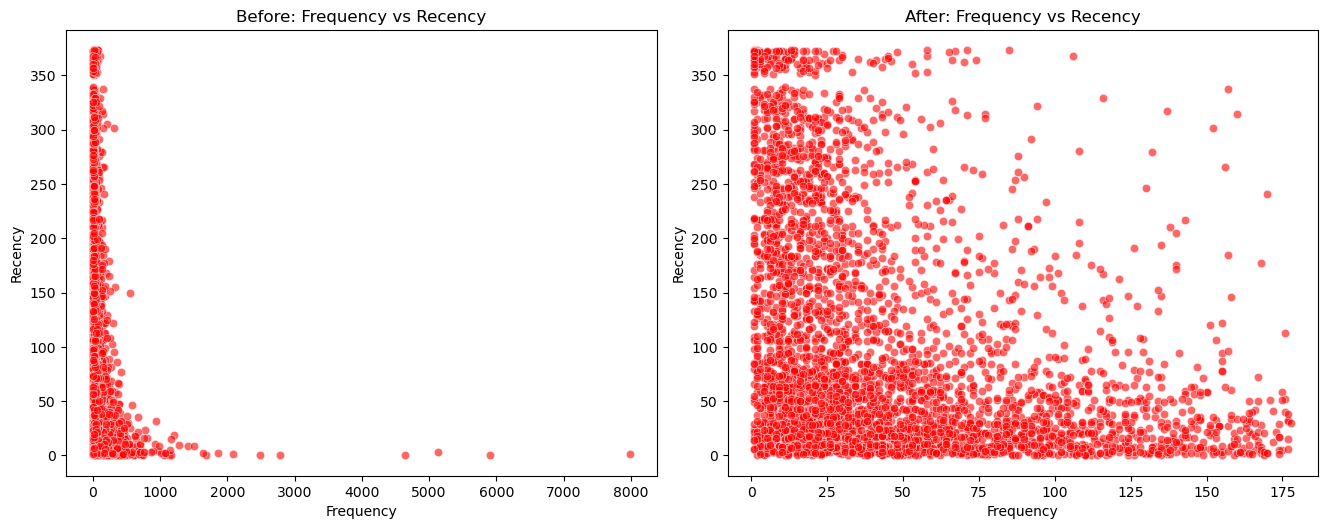

In [67]:
plt.figure(figsize=(20, 10))
# Before Outlier Removal: Frequency vs Recency
plt.subplot(2, 3, 1)
sns.scatterplot(x='Frequency', y='Recency', data=rfm_before, color='red', alpha=0.6)
plt.title('Before: Frequency vs Recency')
plt.xlabel('Frequency')
plt.ylabel('Recency')

# After Outlier Removal: Frequency vs Recency
plt.subplot(2, 3, 2)
sns.scatterplot(x='Frequency', y='Recency', data=rfm_after_recency, color='red', alpha=0.6)
plt.title('After: Frequency vs Recency')
plt.xlabel('Frequency')
plt.ylabel('Recency')

plt.tight_layout()
plt.show()


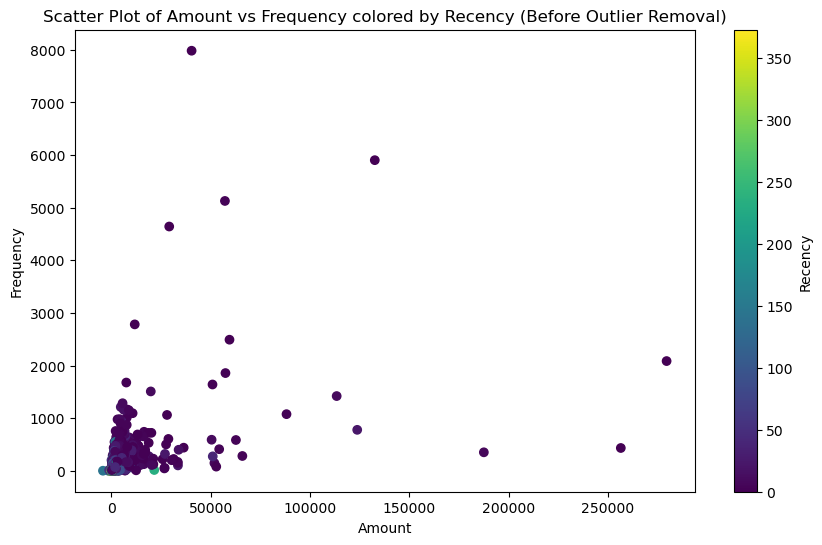

In [68]:
import matplotlib.pyplot as plt

# Assuming rfm_before is your DataFrame with the features 'Amount', 'Frequency', and 'Recency' before outlier removal
plt.figure(figsize=(10, 6))
scatter = plt.scatter(rfm_before['Amount'], rfm_before['Frequency'], c=rfm_before['Recency'], cmap='viridis')
plt.colorbar(scatter, label='Recency')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.title('Scatter Plot of Amount vs Frequency colored by Recency (Before Outlier Removal)')
plt.show()


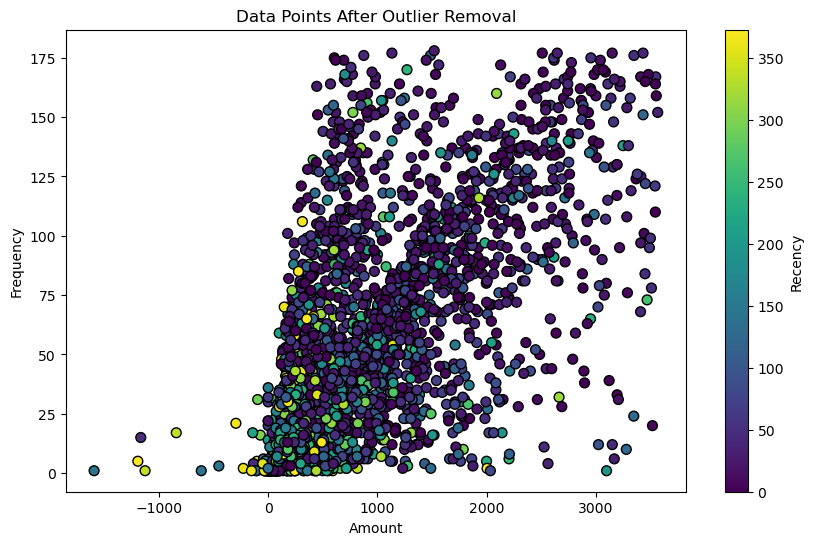

In [69]:

# Plot the data points after outlier removal
plt.figure(figsize=(10, 6))
plt.scatter(rfm_after_recency['Amount'], rfm_after_recency['Frequency'], c=rfm_after_recency['Recency'], cmap='viridis', marker='o', edgecolor='k', s=50)
plt.colorbar(label='Recency')  # Add a colorbar to show the Recency values
plt.title('Data Points After Outlier Removal')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()


# Before outliers removal vs after outliers removal

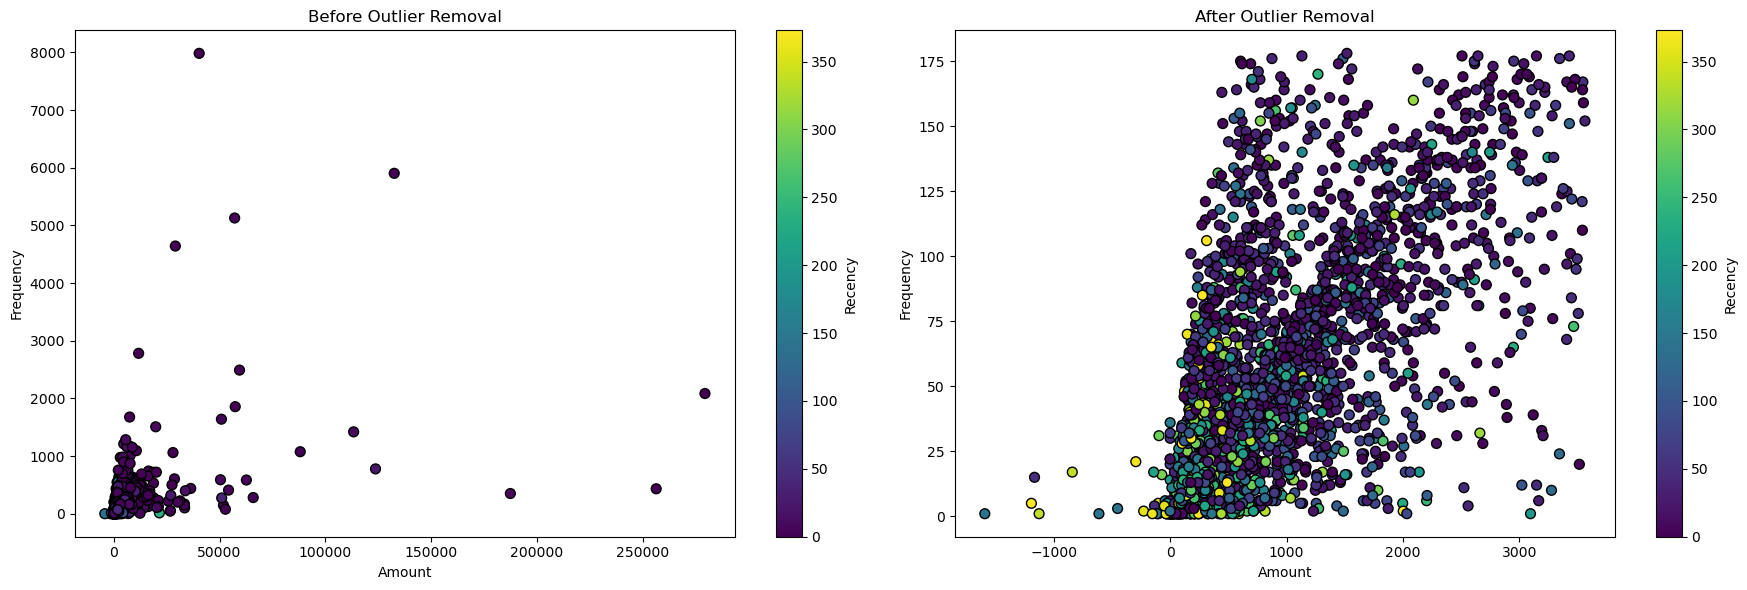

In [71]:
# Create a figure with 1 row and 2 columns for side-by-side comparison
plt.figure(figsize=(18, 6))

# Plot before outlier removal
plt.subplot(1, 2, 1)
plt.scatter(rfm['Amount'], rfm['Frequency'], c=rfm['Recency'], cmap='viridis', marker='o', edgecolor='k', s=50)
plt.colorbar(label='Recency')  # Add a colorbar to show the Recency values
plt.title('Before Outlier Removal')
plt.xlabel('Amount')
plt.ylabel('Frequency')

# Plot after outlier removal
plt.subplot(1, 2, 2)
plt.scatter(rfm_after_recency['Amount'], rfm_after_recency['Frequency'], c=rfm_after_recency['Recency'], cmap='viridis', marker='o', edgecolor='k', s=50)
plt.colorbar(label='Recency')  # Add a colorbar to show the Recency values
plt.title('After Outlier Removal')
plt.xlabel('Amount')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


In [72]:
# Display the data before scaling
print("Data before scaling:")
print(rfm_after_recency.head())

Data before scaling:
  CustomerID   Amount  Frequency  Recency
0      12346     0.00          2      325
2      12348  1797.24         31       74
3      12349  1757.55         73       18
4      12350   334.40         17      309
5      12352  1545.41         95       35


# Scaling the features

In [74]:
# Initialize the scaler
scaler = StandardScaler()

In [75]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Select features to scale
features = ['Amount', 'Frequency', 'Recency']
rfm_scaled = rfm_after_recency.copy()  # Use the data after outlier removal

# Apply scaling
rfm_scaled[features] = scaler.fit_transform(rfm_scaled[features])

# Display the scaled data
print(rfm_scaled.head())


  CustomerID    Amount  Frequency   Recency
0      12346 -1.041614  -1.070949  2.136422
2      12348  1.385298  -0.375498 -0.282050
3      12349  1.331702   0.631707 -0.821629
4      12350 -0.590055  -0.711233  1.982257
5      12352  1.045238   1.159290 -0.657828


In [76]:
# Display descriptive statistics for original data
print("Original Data Statistics:")
print(rfm_after_recency.describe())

# Display descriptive statistics for scaled data
print("\nScaled Data Statistics:")
print(rfm_scaled.describe())


Original Data Statistics:
            Amount    Frequency      Recency
count  3697.000000  3697.000000  3697.000000
mean    771.363098    46.658101   103.272383
std     740.646223    41.705211   103.798588
min   -1592.490000     1.000000     0.000000
25%     248.100000    15.000000    22.000000
50%     508.460000    32.000000    60.000000
75%    1046.560000    68.000000   169.000000
max    3563.850000   178.000000   373.000000

Scaled Data Statistics:
             Amount     Frequency       Recency
count  3.697000e+03  3.697000e+03  3.697000e+03
mean   3.843888e-17 -1.345361e-17  2.018041e-17
std    1.000135e+00  1.000135e+00  1.000135e+00
min   -3.192041e+00 -1.094930e+00 -9.950651e-01
25%   -7.065909e-01 -7.591949e-01 -7.830875e-01
50%   -3.550125e-01 -3.515168e-01 -4.169444e-01
75%    3.716135e-01  5.118014e-01  6.333083e-01
max    3.770848e+00  3.149718e+00  2.598919e+00


In [77]:
rfm_scaled.head(20)

,CustomerID,Amount,Frequency,Recency
0,12346,-1.041614,-1.070949,2.136422
2,12348,1.385298,-0.375498,-0.282050
3,12349,1.331702,0.631707,-0.821629
4,12350,-0.590055,-0.711233,1.982257
5,12352,1.045238,1.159290,-0.657828
6,12353,-0.921432,-1.022987,0.960910
7,12354,0.415959,0.271991,1.230700
8,12355,-0.421261,-0.807157,1.057264
9,12356,2.754814,0.295972,-0.783088
11,12358,0.535682,-0.663271,-0.985430


# Elbow Method

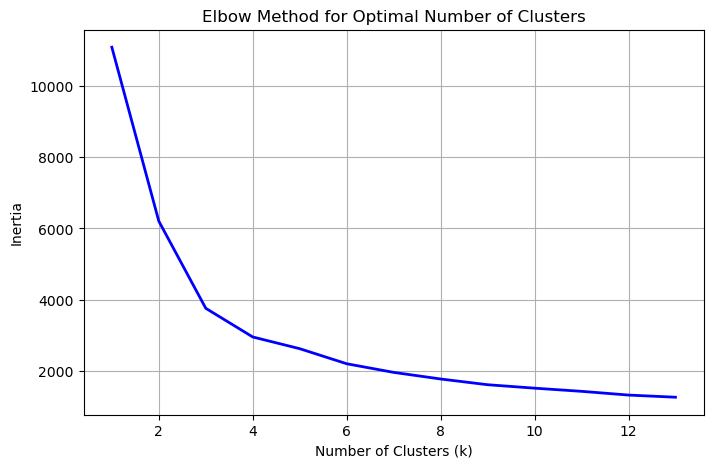

In [79]:
# Define the range for k
K = range(1, 14)
inertia = []

for k in K:
    kmeans = KMeans(n_clusters=k, max_iter=50, random_state=42)
    kmeans.fit(rfm_scaled[['Amount', 'Frequency', 'Recency']])
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'b-', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.grid(True)
plt.show()


In [80]:
inertia

[11091.0,
 6206.330006580112,
 3758.031833753293,
 2952.9218593152414,
 2623.7302772468256,
 2200.663402134741,
 1958.1798267537047,
 1772.4165201277012,
 1611.5835247116966,
 1514.7360653730457,
 1426.112915371454,
 1321.0594491012537,
 1260.4799087584115]

In [81]:
from sklearn.metrics import silhouette_score

# Define the range for k
K = range(2, 14)  # Start from 2 because silhouette score is not defined for 1 cluster
silhouette_scores = []

for k in K:
    kmeans = KMeans(n_clusters=k, max_iter=50, random_state=42)
    kmeans.fit(rfm_scaled[['Amount', 'Frequency', 'Recency']])
    cluster_labels = kmeans.labels_
    silhouette_avg = silhouette_score(rfm_scaled[['Amount', 'Frequency', 'Recency']], cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Print silhouette scores
for k, s in zip(K, silhouette_scores):
    print(f"No. of clusters: {k}, Silhouette Score: {s}")


No. of clusters: 2, Silhouette Score: 0.42929467976639346
No. of clusters: 3, Silhouette Score: 0.43943314570762265
No. of clusters: 4, Silhouette Score: 0.40851721359807264
No. of clusters: 5, Silhouette Score: 0.3424139322048719
No. of clusters: 6, Silhouette Score: 0.35693545614986955
No. of clusters: 7, Silhouette Score: 0.33548432288768654
No. of clusters: 8, Silhouette Score: 0.34155389438224926
No. of clusters: 9, Silhouette Score: 0.34829750980701407
No. of clusters: 10, Silhouette Score: 0.34804268810133576
No. of clusters: 11, Silhouette Score: 0.3177546257089792
No. of clusters: 12, Silhouette Score: 0.3052839660848216
No. of clusters: 13, Silhouette Score: 0.3056990715139446


Optimal Number of Clusters
Highest Silhouette Score: k=2 (0.60789) → This suggests that 2 clusters provide the best separation and cohesion for your data.

Second Best: k=3 (0.50374) → While lower than k=2, it’s still a reasonable choice, especially if business logic aligns with 3 clusters (e.g., low/mid/high).

Other Values: Scores decrease as k increases beyond 3, indicating diminishing returns (more clusters add complexity without meaningful separation).

2. Key Observations
k=2 is Strongest: The score of 0.60789 for 2 clusters implies:

Clear separation between clusters.

Data points within clusters are tightly grouped.

k=3 is Acceptable: A score of 0.50374 suggests:

Moderate separation between clusters.

Clusters are still meaningful but less distinct than with k=2.

Beyond k=3: Scores drop steadily, suggesting overfitting (e.g., splitting natural groups into arbitrary smaller clusters).

3. Comparison to Elbow Method
If Your Elbow Method Suggested k=3: This is a common tension! The Elbow Method prioritizes reducing variance (inertia), while Silhouette prioritizes cluster separation.

Resolution:

Trust k=2 if you want statistically optimal clusters.

Use k=3 if business needs align with three segments (e.g., low/mid/high tiers).



In [91]:
from sklearn.cluster import KMeans

# Define the number of clusters (change k if needed)
k = 3

# Fit KMeans model
kmeans = KMeans(n_clusters=k, random_state=42)
rfm_scaled['Cluster'] = kmeans.fit_predict(rfm_scaled[['Amount', 'Frequency', 'Recency']])


In [93]:
rfm_scaled

,CustomerID,Amount,Frequency,Recency,Cluster
0,12346,-1.041614,-1.070949,2.136422,1
2,12348,1.385298,-0.375498,-0.282050,2
3,12349,1.331702,0.631707,-0.821629,0
4,12350,-0.590055,-0.711233,1.982257,1
5,12352,1.045238,1.159290,-0.657828,0
...,...,...,...,...,...
4366,18278,-0.806787,-0.903081,-0.291685,2
4367,18280,-0.797740,-0.879100,1.673926,1
4368,18281,-0.932478,-0.951043,0.739297,1
4369,18282,-0.803141,-0.807157,-0.927618,2


In [95]:
print(rfm_scaled[['Amount', 'Frequency', 'Recency']].describe())


             Amount     Frequency       Recency
count  3.697000e+03  3.697000e+03  3.697000e+03
mean   3.843888e-17 -1.345361e-17  2.018041e-17
std    1.000135e+00  1.000135e+00  1.000135e+00
min   -3.192041e+00 -1.094930e+00 -9.950651e-01
25%   -7.065909e-01 -7.591949e-01 -7.830875e-01
50%   -3.550125e-01 -3.515168e-01 -4.169444e-01
75%    3.716135e-01  5.118014e-01  6.333083e-01
max    3.770848e+00  3.149718e+00  2.598919e+00


In [97]:
# Get the number of rows in the DataFrame
num_rows = len(rfm_scaled)
print(f"Number of rows in the DataFrame: {num_rows}")


Number of rows in the DataFrame: 3697


In [99]:
print(rfm_scaled.columns)


Index(['CustomerID', 'Amount', 'Frequency', 'Recency', 'Cluster'], dtype='object')


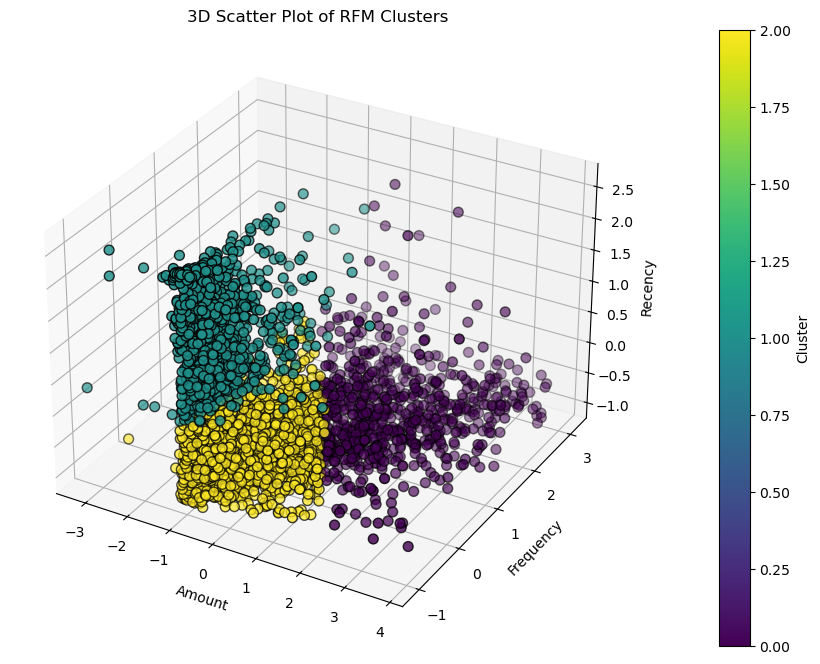

In [101]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create a new figure for 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
sc = ax.scatter(rfm_scaled['Amount'], rfm_scaled['Frequency'], rfm_scaled['Recency'], 
                c=rfm_scaled['Cluster'], cmap='viridis', s=50, edgecolor='k')

# Adding titles and labels
ax.set_title('3D Scatter Plot of RFM Clusters')
ax.set_xlabel('Amount')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')

# Adding color bar
color_bar = fig.colorbar(sc, ax=ax, pad=0.1)
color_bar.set_label('Cluster')

# Show the plot
plt.show()


In [103]:
def categorize_customer(row):
    # Example thresholds for standardized data
    if row['Recency'] <= 1 and row['Frequency'] >= 1 and row['Amount'] >= 1:
        return 'Champions'
    elif row['Frequency'] >= 0.5 and row['Amount'] >= 0.5:
        return 'Loyal Customers'
    elif row['Recency'] <= 1 and row['Frequency'] <= 0.5:
        return 'New Customers'
    elif row['Recency'] > 1 and row['Frequency'] >= 0.5 and row['Amount'] >= 0.5:
        return 'At Risk'
    elif row['Recency'] > 1 and row['Frequency'] <= 0.5:
        return 'Lost'
    else:
        return 'Other'

# Apply the function to categorize customers
rfm_scaled['Segment'] = rfm_scaled.apply(categorize_customer, axis=1)

# Show results
print(rfm_scaled[['CustomerID', 'Amount', 'Frequency', 'Recency', 'Segment']].head())


  CustomerID    Amount  Frequency   Recency          Segment
0      12346 -1.041614  -1.070949  2.136422             Lost
2      12348  1.385298  -0.375498 -0.282050    New Customers
3      12349  1.331702   0.631707 -0.821629  Loyal Customers
4      12350 -0.590055  -0.711233  1.982257             Lost
5      12352  1.045238   1.159290 -0.657828        Champions


           Segment  Count
0    New Customers   2101
1             Lost    669
2        Champions    351
3            Other    350
4  Loyal Customers    226


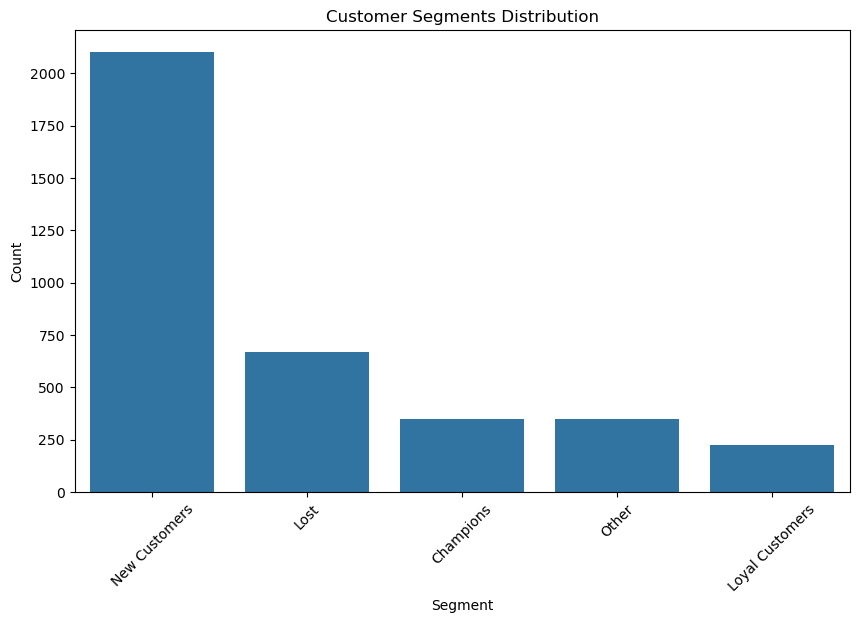

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt

# Analyze the distribution of segments
segment_summary = rfm_scaled['Segment'].value_counts().reset_index()
segment_summary.columns = ['Segment', 'Count']
print(segment_summary)

# Visualize the distribution of segments
plt.figure(figsize=(10, 6))
sns.countplot(x='Segment', data=rfm_scaled, order=segment_summary['Segment'])
plt.title('Customer Segments Distribution')
plt.xlabel('Segment')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


Summary of Segmentation

Champions: Recent (Recency <= 30), frequent (Frequency >= 10), and high-spending (Amount >= 1000) customers.
Loyal Customers: Frequent (Frequency >= 5) and high-spending (Amount >= 500) customers.
New Customers: Recent (Recency <= 30) customers with only one or two purchases (Frequency <= 2).
At Risk: Customers who used to buy frequently (Frequency >= 5) and spend a lot (Amount >= 500) but have not purchased recently (Recency > 180).
Lost: Customers who haven’t purchased for a long time (Recency > 180) and have a low frequency of purchases (Frequency <= 2).
